# Modul 10: Deployment & MLOps

**Project-Based Internship VINIX7**

Kelompok 3 (Universitas Sultan Ageng Tirtayasa)

Anggota Kelompok: Ahmad Jumhadi, Azhriler Lintang, Aura Salsa Azzahra

# Tahap 1: Persiapan Data & Serialisasi Model

In [ ]:
!kaggle datasets download -d salmanabdu/tokopedia-product-reviews-2025
!unzip -o tokopedia-product-reviews-2025.zip
!pip install Sastrawi flake8 --quiet

Dataset URL: https://www.kaggle.com/datasets/salmanabdu/tokopedia-product-reviews-2025
License(s): MIT
tokopedia-product-reviews-2025.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  tokopedia-product-reviews-2025.zip
  inflating: tokopedia_product_reviews_2025.csv  


Pada tahap awal, dilakukan pengambilan dataset menggunakan Kaggle API. Dataset diunduh secara otomatis dari platform Kaggle sehingga data dapat langsung digunakan dalam proses analisis tanpa perlu mengunduh secara manual. Setelah itu, file dataset yang masih dalam format .zip diekstrak menggunakan perintah unzip agar file-file di dalamnya dapat diakses dan diproses lebih lanjut.

Dilakukan juga instalasi beberapa library pendukung, yaitu Sastrawi dan flake8. Library Sastrawi digunakan untuk proses preprocessing teks bahasa Indonesia, khususnya stemming atau mengubah kata berimbuhan menjadi kata dasar sehingga analisis teks menjadi lebih konsisten. Sementara itu, flake8 digunakan sebagai tools untuk pengecekan kualitas dan kerapihan kode Python.

In [ ]:
%%writefile text_cleaner.py
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stop_factory = StopWordRemoverFactory()
base_stopwords = stop_factory.get_stop_words()
negation_words = {'tidak', 'bukan', 'kurang', 'belum', 'gk', 'ga'}
custom_stopwords = set(base_stopwords) - negation_words

stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

slang_registry = {
    "yg": "yang", "gk": "tidak", "ga": "tidak", "bgt": "banget",
    "recomended": "rekomendasi", "tp": "tapi", "jlk": "jelek",
    "ok": "bagus", "dgn": "dengan", "smp": "sampai", "blm": "belum"
}

def elite_clean(text):
    text = str(text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)

    tokens = text.split()
    mapped_tokens = [slang_registry.get(t, t) for t in tokens]

    joined_text = " ".join(mapped_tokens)
    stemmed_text = stemmer.stem(joined_text)

    stemmed_text = re.sub(r'\b(tidak|bukan|kurang|belum)\s+([a-z]+)', r'\1_\2', stemmed_text)
    final_tokens = [t for t in stemmed_text.split() if t not in custom_stopwords]
    return " ".join(final_tokens)

Writing text_cleaner.py


Pada tahap ini dibuat sebuah file Python bernama text_cleaner.py untuk melakukan preprocessing teks ulasan sebelum digunakan dalam analisis sentimen. Library re digunakan untuk membersihkan teks, sedangkan Sastrawi digunakan untuk stemming dan stopword removal pada teks bahasa Indonesia.

Selanjutnya dibuat daftar stopword dengan tetap mempertahankan kata negasi seperti “tidak”, “bukan”, dan “belum” karena berpengaruh terhadap makna sentimen suatu kalimat. Selain itu, dibuat slang_registry untuk mengubah kata tidak baku seperti “gk”, “yg”, dan “bgt” menjadi bentuk formal agar teks lebih konsisten.

Fungsi elite_clean(text) kemudian digunakan untuk melakukan beberapa tahapan preprocessing, seperti menghapus emoji, angka, dan tanda baca, mengubah huruf menjadi lowercase, normalisasi kata slang, serta stemming menjadi kata dasar. Kode juga menggabungkan kata negasi dengan kata setelahnya, seperti tidak_bagus, agar makna negatif tetap terjaga. Setelah itu, stopword dihapus sehingga menghasilkan teks yang lebih bersih dan siap digunakan dalam proses analisis.

In [ ]:
import pandas as pd
import numpy as np
import os

def get_target_file():
    for file in os.listdir('.'):
        if file.endswith('.csv') and 'tokopedia' in file.lower():
            return file
    raise FileNotFoundError("File dataset tidak ditemukan.")

def load_raw_dataset(filepath):
    df = pd.read_csv(filepath)
    df = df.dropna(subset=['review_text', 'rating'])
    df = df.drop_duplicates(subset=['review_text'])
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
    df = df.dropna(subset=['rating'])
    return df

def label_sentiment(rating):
    if rating > 3: return "Positif"
    elif rating < 3: return "Negatif"
    else: return "Netral"

if __name__ == "__main__":
    file_path = get_target_file()
    df = load_raw_dataset(file_path)
    df['Sentimen'] = df['rating'].apply(label_sentiment)
    df_sampled = df.sample(n=min(5000, len(df)), random_state=42).copy()

Pada tahap ini dilakukan proses pembacaan dan persiapan dataset ulasan Tokopedia. Fungsi get_target_file() digunakan untuk mencari file dataset secara otomatis dengan format .csv yang memiliki nama mengandung kata “tokopedia”, sehingga proses pemanggilan dataset menjadi lebih fleksibel.

Selanjutnya, fungsi load_raw_dataset(filepath) digunakan untuk membersihkan data awal dengan menghapus data null pada kolom 'review_text' dan 'rating', menghapus data duplikat berdasarkan kolom 'review_text', serta memastikan kolom 'rating' bertipe numerik. Jika terdapat nilai rating yang tidak valid, data tersebut juga akan dihapus agar kualitas dataset tetap terjaga.

Lalu dibuat juga fungsi label_sentiment(rating) untuk memberikan label sentimen berdasarkan nilai rating. Rating di atas 3 dikategorikan sebagai sentimen positif, rating di bawah 3 sebagai negatif, sedangkan rating 3 dikategorikan sebagai netral.

Pada bagian utama program, dataset dimuat dan dilakukan penambahan kolom 'Sentimen' berdasarkan hasil pelabelan rating. Setelah itu, data diambil sebanyak maksimal 5000 sampel secara acak menggunakan random_state=42 agar hasil sampling tetap konsisten.

In [ ]:
import json
import pickle
import time
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from text_cleaner import elite_clean

def run_elite_modeling(df):
    X = df['review_text']
    y = df['Sentimen']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    baseline = DummyClassifier(strategy='stratified', random_state=42)
    baseline.fit(X_train, y_train)
    baseline_acc = accuracy_score(y_test, baseline.predict(X_test))

    base_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(preprocessor=elite_clean, min_df=3)),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
    ])

    param_grid = {
        'tfidf__ngram_range': [(1, 1), (1, 2)],
        'tfidf__max_features': [3000, 5000],
        'classifier__C': [1.0, 10.0]
    }

    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid_search = GridSearchCV(base_pipeline, param_grid, cv=cv_strategy, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    classes = best_model.classes_

    print("=== 1. Hyperparameter & CV Results ===")
    print(f"Best Params: {grid_search.best_params_}")
    print(f"Baseline Accuracy: {baseline_acc * 100:.2f}%")

    print("\n=== 2. Classification Report ===")
    print(classification_report(y_test, y_pred))

    print("=== 3. Confusion Matrix ===")
    print(confusion_matrix(y_test, y_pred, labels=classes))

    print("\n=== 4. Engineering Insights ===")
    insight_msg = """Model improvement over baseline is minor due to extreme data imbalance
    (Positive class ~97%). Pipeline-integrated preprocessing with token negation
    binding successfully prevents training-serving skew and data leakage."""
    print(insight_msg)

    return best_model, X_test, y_test, y_pred, grid_search.best_params_, insight_msg

def log_experiment_metadata(params, metrics, insight):
    run_log = {
        "timestamp": time.time(),
        "experiment_name": "Tokopedia_Pipeline_Integrated_Elite",
        "parameters": params,
        "metrics": metrics,
        "insights": insight
    }
    with open("experiment_tracking.json", "w") as f:
        json.dump(run_log, f, indent=4)

def export_production_artifacts(model, X_test, y_test, y_pred, params, insight):
    os.makedirs("registry/v1_2_0", exist_ok=True)
    with open("registry/v1_2_0/model_tokopedia.pkl", "wb") as f:
        pickle.dump(model, f)
    with open("model_tokopedia.pkl", "wb") as f:
        pickle.dump(model, f)

    metrics = {
        "model_version": "1.2.0",
        "accuracy": round(accuracy_score(y_test, y_pred) * 100, 2),
        "f1_weighted": round(f1_score(y_test, y_pred, average='weighted') * 100, 2),
        "total_test_samples": len(X_test)
    }
    with open("metrics.json", "w") as f:
        json.dump(metrics, f)
    log_experiment_metadata(params, metrics, insight)

if __name__ == "__main__":
    best_model, X_test, y_test, y_pred, params, insight = run_elite_modeling(df_sampled)
    export_production_artifacts(best_model, X_test, y_test, y_pred, params, insight)

=== 1. Hyperparameter & CV Results ===
Best Params: {'classifier__C': 10.0, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}
Baseline Accuracy: 94.50%

=== 2. Classification Report ===
              precision    recall  f1-score   support

     Negatif       0.27      0.21      0.24        14
      Netral       0.06      0.08      0.07        12
     Positif       0.98      0.98      0.98       974

    accuracy                           0.96      1000
   macro avg       0.44      0.43      0.43      1000
weighted avg       0.96      0.96      0.96      1000

=== 3. Confusion Matrix ===
[[  3   3   8]
 [  1   1  10]
 [  7  14 953]]

=== 4. Engineering Insights ===
Model improvement over baseline is minor due to extreme data imbalance 
    (Positive class ~97%). Pipeline-integrated preprocessing with token negation 
    binding successfully prevents training-serving skew and data leakage.


Pada tahap ini dilakukan proses pemodelan analisis sentimen menggunakan algoritma Logistic Regression dengan pendekatan pipeline machine learning. Sebelum membangun model utama, digunakan DummyClassifier sebagai baseline model untuk mengetahui performa dasar klasifikasi secara acak berdasarkan distribusi data. Hasil baseline accuracy sebesar 94,50% menunjukkan bahwa dataset sangat didominasi oleh kelas positif, sehingga model sederhana sudah mampu memperoleh akurasi tinggi.

Model utama dibangun menggunakan Pipeline yang mengintegrasikan preprocessing teks elite_clean, ekstraksi fitur TF-IDF, dan algoritma Logistic Regression dengan class_weight='balanced' untuk membantu menangani ketidakseimbangan data. Selanjutnya dilakukan hyperparameter tuning menggunakan GridSearchCV dan StratifiedKFold untuk mencari kombinasi parameter terbaik. Hasil tuning menunjukkan parameter terbaik yaitu C=10.0, max_features=3000, dan ngram_range=(1,2).

Hasil evaluasi menunjukkan model memperoleh accuracy sebesar 96%. Namun, performa pada kelas negatif dan netral masih rendah, terlihat dari nilai precision, recall, dan f1-score yang kecil. Hal ini terjadi karena distribusi data sangat tidak seimbang, di mana sekitar 97% data termasuk kelas positif. Confusion matrix juga menunjukkan bahwa sebagian besar data negatif dan netral masih sering diprediksi sebagai positif.

In [ ]:
import json
import numpy as np

def calculate_distribution_drift(historical_dist, current_dist):
    historical_probs = np.array(historical_dist) / sum(historical_dist)
    current_probs = np.array(current_dist) / sum(current_dist)
    epsilon = 1e-4
    historical_probs = np.where(historical_probs == 0, epsilon, historical_probs)
    current_probs = np.where(current_probs == 0, epsilon, current_probs)
    return np.sum((current_probs - historical_probs) * np.log(current_probs / historical_probs))

if __name__ == "__main__":
    historical_distribution = [970, 20, 10]
    mock_production_inference_distribution = [850, 90, 60]
    drift_index = calculate_distribution_drift(historical_distribution, mock_production_inference_distribution)

    print("=== MLOps Telemetry Log ===")
    print(f"Skor Data Drift Distribusi Target: {drift_index:.4f}")
    if drift_index > 0.1:
        print("[WARNING] Terdeteksi Data Drift signifikan pada lingkungan produksi!")

=== MLOps Telemetry Log ===
Skor Data Drift Distribusi Target: 0.2107
[WARNING] Terdeteksi Data Drift signifikan pada lingkungan produksi!


Pada tahap ini dilakukan simulasi monitoring model untuk mendeteksi data drift pada lingkungan produksi. Kode menggunakan distribusi historis data training dan membandingkannya dengan distribusi data hasil inferensi terbaru di produksi. Perhitungan dilakukan menggunakan metode divergence berbasis probabilitas untuk mengukur seberapa besar perubahan distribusi antar data.

Distribusi historis menunjukkan data didominasi oleh sentimen positif, sedangkan pada data produksi terjadi peningkatan jumlah sentimen negatif dan netral. Hasil perhitungan menghasilkan skor drift sebesar 0,2107. Karena nilai tersebut melebihi threshold 0,1, sistem memberikan peringatan bahwa terdeteksi data drift yang signifikan pada lingkungan produksi.

Hal ini menunjukkan bahwa pola data baru mulai berbeda dari data saat model dilatih, sehingga performa model berpotensi menurun jika tidak dilakukan monitoring atau retraining secara berkala.

# Tahap 2: Pengembangan Dashboard Streamlit

In [ ]:
%%writefile app.py
import streamlit as st
import pickle
import json


def load_production_pipeline():
    with open("model_tokopedia.pkl", "rb") as file:
        return pickle.load(file)


def load_telemetry_metrics():
    try:
        with open("metrics.json", "r") as file:
            return json.load(file)
    except FileNotFoundError:
        return {"model_version": "0.0.0", "accuracy": 0.0, "total_test_samples": 0}


def render_dashboard():
    st.set_page_config(page_title="Tokopedia Sentiment Analytics", page_icon="🛍️", layout="wide")
    st.title("🛍️ Sentiment Analytics Dashboard")
    st.caption("Enterprise-grade customer review classification system powered by MLOps Pipeline.")
    st.write("---")

    tab1, tab2 = st.tabs(["🔮 Single Review Inference", "📊 Model Performance Insights"])

    with tab1:
        col1, col2 = st.columns([2, 1], gap="large")
        with col1:
            st.subheader("Input Customer Review")
            user_input = st.text_area("Masukkan ulasan pelanggan platform Tokopedia:", height=150, placeholder="Tulis ulasan di sini...")
            predict_button = st.button("Analyze Sentiment", type="primary", use_container_width=True)
        with col2:
            st.subheader("Classification Result")
            if predict_button and user_input.strip() != "":
                try:
                    pipeline = load_production_pipeline()
                    prediction = pipeline.predict([user_input])[0]
                    if prediction == "Positif":
                        st.success("### 😊 POSITIF")
                    elif prediction == "Netral":
                        st.info("### 😐 NETRAL")
                    else:
                        st.error("### 😡 NEGATIF")
                except FileNotFoundError:
                    st.error("Model file tidak ditemukan.")
            else:
                st.info("Menunggu input ulasan teks.")

    with tab2:
        st.subheader("Model Production Artifacts")
        metrics = load_telemetry_metrics()
        m1, m2, m3 = st.columns(3)
        with m1:
            st.markdown(f"### 📦 v{metrics['model_version']}")
            st.caption("Active Model Version")
        with m2:
            st.markdown(f"### 📊 {metrics['accuracy']}%")
            st.caption("Cross-Validated Accuracy")
        with m3:
            st.markdown(f"### 📁 {metrics['total_test_samples']:,}")
            st.caption("Evaluated Test Samples")


if __name__ == "__main__":
    render_dashboard()

Overwriting app.py


Pada tahap ini dibuat aplikasi deployment menggunakan Streamlit untuk menampilkan sistem analisis sentimen dalam bentuk dashboard interaktif. Aplikasi diawali dengan proses memuat model machine learning yang telah disimpan dalam file model_tokopedia.pkl menggunakan library pickle, sehingga model dapat digunakan kembali tanpa perlu melakukan training ulang.

Selain itu, aplikasi juga memuat file metrics.json yang berisi informasi performa model seperti versi model, accuracy, dan jumlah data testing. Jika file metrics tidak ditemukan, sistem akan menggunakan nilai default agar aplikasi tetap dapat berjalan.

Fungsi render_dashboard() digunakan untuk membangun tampilan dashboard. Pada bagian awal, aplikasi mengatur konfigurasi halaman seperti judul, ikon, dan layout. Dashboard kemudian dibagi menjadi dua tab utama, yaitu tab prediksi sentimen dan tab informasi performa model.

Pada tab pertama, pengguna dapat memasukkan ulasan pelanggan melalui text area yang tersedia. Ketika tombol “Analyze Sentiment” ditekan, sistem akan memproses teks menggunakan pipeline model yang telah dibuat sebelumnya, kemudian menampilkan hasil klasifikasi berupa sentimen positif, netral, atau negatif. Sementara itu, tab kedua digunakan untuk menampilkan informasi model produksi, seperti versi model aktif, nilai accuracy, dan jumlah data testing yang digunakan saat evaluasi model.

In [ ]:
%%writefile test_pipeline.py
import unittest
import os
import pickle
import json
from text_cleaner import elite_clean

class TestTokopediaIntegratedPipeline(unittest.TestCase):

    def test_pipeline_inference_consistency(self):
        with open("model_tokopedia.pkl", "rb") as file:
            pipeline = pickle.load(file)
        raw_input = "Produknya tidak bagus bgt!! Kecewa 😊"
        prediction = pipeline.predict([raw_input])[0]
        self.assertIn(prediction, ["Positif", "Negatif", "Netral"])

    def test_production_artifacts(self):
        self.assertTrue(os.path.exists("model_tokopedia.pkl"))
        self.assertTrue(os.path.exists("metrics.json"))
        self.assertTrue(os.path.exists("text_cleaner.py"))

if __name__ == "__main__":
    unittest.main()

Overwriting test_pipeline.py


Pada tahap ini dibuat file pengujian test_pipeline.py menggunakan unittest untuk memastikan pipeline machine learning dan artefak produksi berjalan dengan baik. Pengujian ini bertujuan untuk memvalidasi bahwa model yang telah dibuat dapat digunakan secara konsisten pada lingkungan deployment.

In [ ]:
!python test_pipeline.py
!flake8 app.py --ignore=E501 || true

..
----------------------------------------------------------------------
Ran 2 tests in 1.565s

OK


Pada tahap ini dilakukan proses pengujian dan validasi kualitas kode pada sistem yang telah dibangun. Hal ini membantu meningkatkan kualitas dan maintainability sistem sebelum deployment ke lingkungan produksi.

## Tahap 3: Deployment & Tunneling

In [ ]:
with open("requirements.txt", "w") as f:
    f.write("streamlit==1.35.0\nscikit-learn==1.3.2\npandas==2.0.3\nnumpy==1.24.3\nSastrawi==1.0.1\n")

with open(".dockerignore", "w") as f:
    f.write("*.zip\n*.csv\nkaggle.json\n.config/\nsample_data/\n__pycache__/\n*.ipynb\ntest_pipeline.py\n")

with open("Dockerfile", "w") as f:
    f.write("""FROM python:3.9-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY app.py model_tokopedia.pkl metrics.json text_cleaner.py ./
RUN useradd -m appuser && chown -R appuser /app
USER appuser
EXPOSE 8501
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0"]
""")

print("=== Sukses: Berkas arsitektur Docker tersemat rapi ===")

!streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false &> /dev/null &

print("\n=== SALIN ANGKA IP INI UNTUK PASSWORD BYPASS ===")
!curl -s ipv4.icanhazip.com
print("================================================\n")

!npx localtunnel --port 8501

=== Sukses: Berkas arsitektur Docker tersemat rapi ===

=== SALIN ANGKA IP INI UNTUK PASSWORD BYPASS ===
34.177.100.5

⠙⠹⠸⠼⠴⠦your url is: https://chatty-seas-hide.loca.lt
^C


Pada tahap ini dilakukan proses persiapan deployment aplikasi menggunakan containerization dengan Docker. Sistem terlebih dahulu membuat file requirements.txt yang berisi daftar library dan versi dependency yang dibutuhkan aplikasi, seperti streamlit, scikit-learn, pandas, numpy, dan Sastrawi.

Selanjutnya dibuat file .dockerignore untuk mengecualikan file yang tidak diperlukan saat proses build Docker, seperti dataset .csv, file .zip, cache Python, notebook, dan file testing.

Setelah itu dibuat Dockerfile sebagai blueprint container aplikasi. Dockerfile mengatur penggunaan base image python:3.9-slim, membuat direktori kerja aplikasi, menginstal dependency dari requirements.txt, menyalin file penting aplikasi, serta menjalankan aplikasi menggunakan Streamlit pada port 8501.

Berikutnya, aplikasi Streamlit dijalankan secara lokal menggunakan konfigurasi tertentu agar dapat diakses melalui jaringan eksternal. Sistem kemudian mengambil alamat IP publik menggunakan curl yang digunakan sebagai password bypass pada layanan tunneling. localtunnel digunakan untuk membuat URL publik sementara sehingga dashboard Streamlit dapat diakses melalui internet tanpa perlu melakukan deployment ke cloud server.

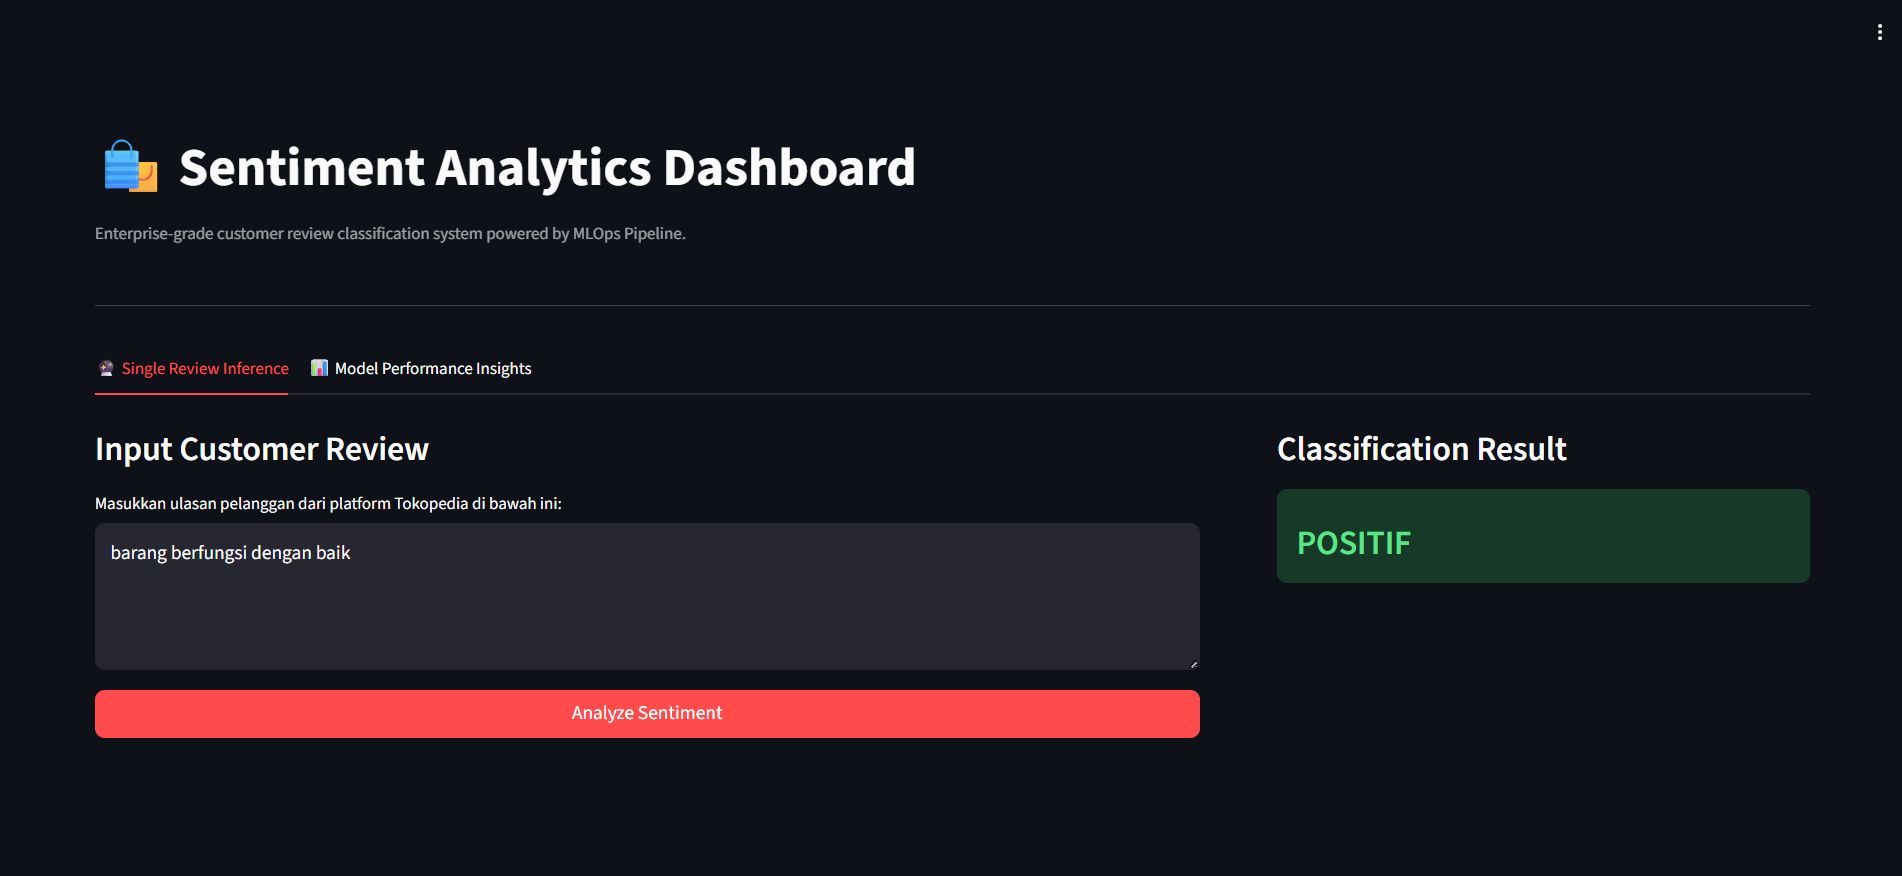

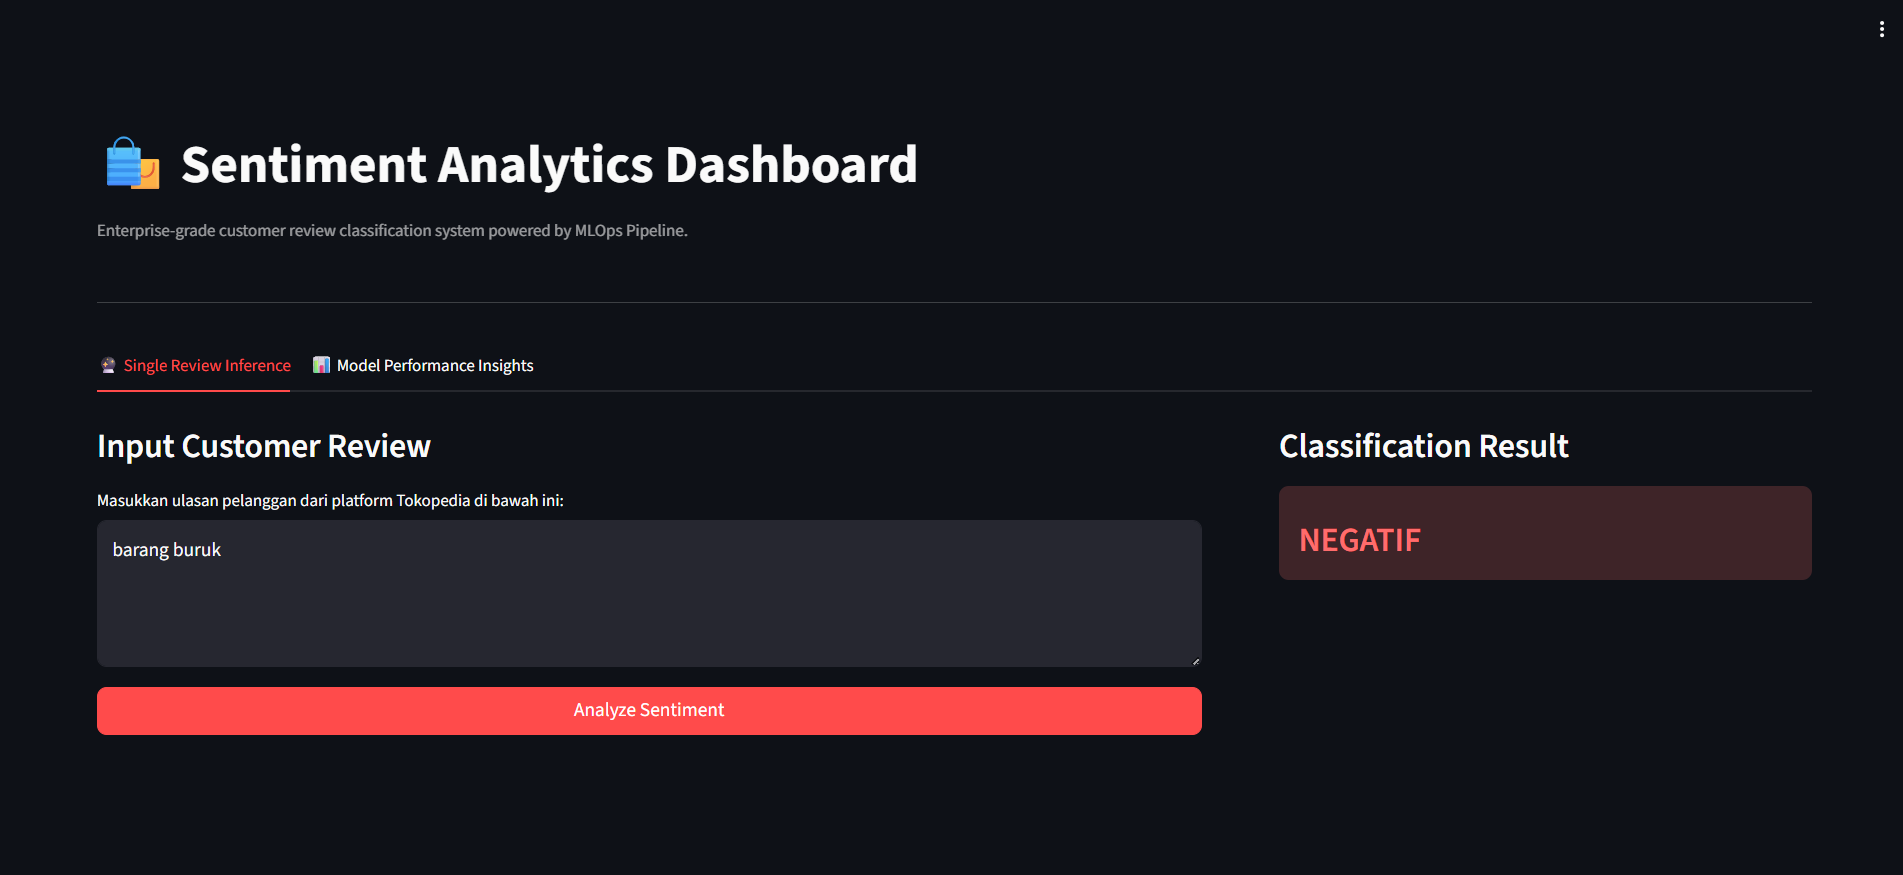

# Tahap 4: Pemahaman MLOps & Containerization

### 1. Draf Dockerfile untuk Aplikasi Streamlit

```dockerfile
FROM python:3.9-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py model_tokopedia.pkl metrics.json text_cleaner.py ./

RUN useradd -m appuser && chown -R appuser /app
USER appuser

EXPOSE 8501

CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0"]

### 2. Monitoring (Data Drift)

**Fenomena:**
Penurunan akurasi prediksi model secara drastis di tahun berikutnya, meskipun tidak ada kode yang diubah, merupakan fenomena yang disebut sebagai **Data Drift** (atau *Concept Drift*). Hal ini terjadi karena distribusi data pada dunia nyata (lingkungan produksi) telah bergeser dan berbeda dari distribusi data historis yang digunakan saat proses pelatihan (*training*). Pada studi kasus ulasan Tokopedia, hal ini bisa disebabkan oleh pergeseran tren bahasa, munculnya istilah/slang baru, atau perubahan perilaku pelanggan seiring berjalannya waktu.
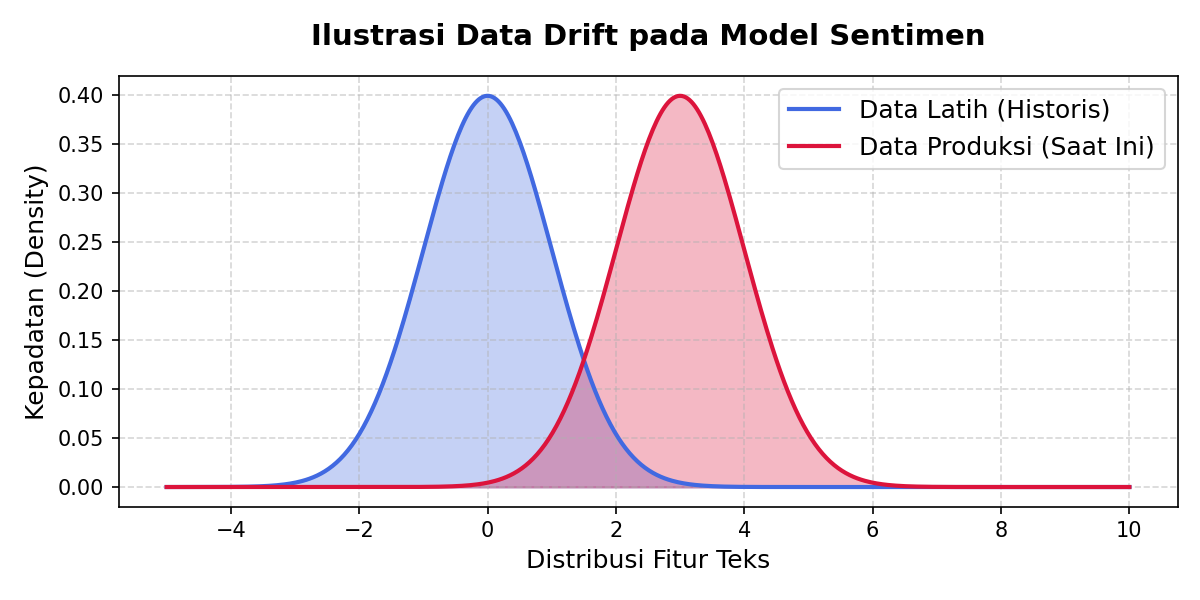

**Solusi MLOps:**

1. **Continuous Monitoring:** Mengimplementasikan sistem pemantauan (seperti yang telah Anda simulasikan di Tahap 1) yang menghitung distribusi data masukan dan membandingkannya dengan data latih secara konstan untuk mendapatkan metrik *divergence* atau skor *drift*.
2. **Automated Retraining:** Menerapkan *pipeline* yang dikonfigurasi agar secara otomatis memicu proses pelatihan ulang (*retraining*) menggunakan data ulasan yang paling baru jika skor *data drift* yang terdeteksi melebihi batas toleransi (*threshold*). Hal ini menjamin bahwa sistem beradaptasi dengan kondisi riil.



### 3. CI/CD (Continuous Integration / Continuous Deployment)

Otomatisasi CI/CD sangat mempermudah tim untuk mengganti versi model mesin ke server baru tanpa menyebabkan *dashboard* mengalami *downtime* (*Zero Downtime Deployment*). Mekanisme ini bekerja melalui:

* **Automated Testing (CI):** Saat versi model baru siap dirilis, *pipeline* CI secara otomatis akan menjalankan skrip pengujian (seperti `test_pipeline.py` yang sudah dibuat) untuk memastikan bahwa model baru berjalan mulus, format input/output sesuai, dan tidak ada kegagalan teknis.
* **Strategi Deployment seperti *Blue-Green Deployment* (CD):** Pembaruan dikemas menggunakan *container* Docker baru secara otomatis. Menggunakan taktik *Blue-Green*, lingkungan produksi saat ini (Blue) yang melayani *user* dibiarkan tetap hidup, sementara model di versi terbaru (Green) dikerahkan dan dipanaskan secara paralel. Saat versi Green dipastikan stabil dan sehat, pengaturan jaringan (*load balancer*) hanya tinggal mengalihkan seluruh *traffic* masuk ke Green secara seketika. Hal ini membuat transisi versi tidak disadari oleh *user* (tanpa *downtime*) dan tim dapat menukar (*rollback*) ke model lama secepat kilat jika terjadi malfungsi tak terduga.